In [1]:
# AMATH 581 HW 4
# Jonathan McCormack 
import numpy as np
import time
import copy
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.sparse.linalg import spsolve, splu, bicgstab, gmres
from scipy.sparse import spdiags
from scipy.fft import fft2, ifft2


#-----------------------
# Exercise 1:
#-----------------------

N = 10
steps = 64
dt = 0.5
tspan = [0,4]
v = 0.001


size = steps**2
x_eval = np.linspace(-N, N, steps, endpoint=False)
y_eval = np.linspace(-N, N, steps, endpoint=False)
d = x_eval[1] - x_eval[0]
t_eval = np.arange(tspan[0], tspan[1]+dt, dt)

eye =np.ones((size))

D1 = np.concatenate((np.ones(steps-1), np.array([0])))
D1 = np.matlib.repmat(D1,1,steps).reshape(size)
DM = np.concatenate((np.array([1]), np.zeros(steps-1)))
DM = np.matlib.repmat(DM,1,steps).reshape(size)

U1 = np.roll(D1,1)
UM = np.roll(DM, steps-1)

#Constructing A
data = np.array((eye, eye, DM, D1, -4*eye, U1, UM, eye, eye))
diags = np.array((-(size-steps), -steps, -steps+1, -1, 0, 1, steps-1, steps , (size-steps)))

A = spdiags(data, diags, size, size, format='csc')
A[0,0] = 2
A = A/(d**2)

# Partial Derivative with respect to x

data = np.array((eye, -eye, eye, -eye))
diags = np.array((-(size-steps), -steps, steps, (size-steps)))

B = spdiags(data, diags, size, size, format='csc')
B = B/(2*d)

# Partial Derivative with respect to y

D1 = np.concatenate((np.ones(steps-1), np.array([0])))
D1 = np.matlib.repmat(D1, 1, steps).reshape(size)

DM = np.concatenate((np.array([1]), np.zeros(steps-1)))
DM = np.matlib.repmat(DM, 1, steps).reshape(size)

U1 = np.roll(D1, 1)
UM = np.roll(DM, steps-1)

data = np.array((DM, -D1, U1, -UM))
diags = np.array((-(steps-1), -1, 1, steps-1))

C = spdiags(data, diags, size, size, format='csc')
C = C/(2*d)

del eye, D1, DM, U1, UM, data, diags



X, Y = np.meshgrid(x_eval, y_eval)
W0 = np.exp(-(X**2)-(Y**2)/20)
w0_val = W0.reshape(size, order='F')


def rhs_ode_GE(t, w, A, B, C):
        
        psi = spsolve(A, w)
        psi_x = B@psi
        psi_y = C@psi
        w_x = B@w
        w_y = C@w
        dw_t = v*(A)@w - np.multiply(psi_x,w_y) + np.multiply(psi_y,w_x)
        
        return dw_t

def rhs_ode_LU(t, w, A, B, C):
        
        plu = splu(A)
        psi = plu.solve(w)
        psi_x = B@psi
        psi_y = C@psi
        w_x = B@w
        w_y = C@w
        dw_t = v*(A)@w - np.multiply(psi_x,w_y) + np.multiply(psi_y,w_x)
        
        return dw_t

def rhs_ode_bicgstab(t, w, A, B, C):
        
        psi, exit = bicgstab(A, w)
        psi_x = B@psi
        psi_y = C@psi
        w_x = B@w
        w_y = C@w
        dw_t = v*(A)@w - np.multiply(psi_x,w_y) + np.multiply(psi_y,w_x)
         
        
        return dw_t

def rhs_ode_gmres(t, w, A, B, C):
        
        psi, exit = gmres(A, w)
        psi_x = B@psi
        psi_y = C@psi
        w_x = B@w
        w_y = C@w
        dw_t = v*(A)@w - np.multiply(psi_x,w_y) + np.multiply(psi_y,w_x)
         
        
        return dw_t



tic = time.time()
sol_GE = solve_ivp(rhs_ode_GE, tspan, w0_val, t_eval = t_eval, args = [A, B, C])
A1 = copy.deepcopy(sol_GE.y.T)
toc = time.time()
print(toc-tic)

tic = time.time()
sol_LU = solve_ivp(rhs_ode_LU, tspan, w0_val, t_eval = t_eval, args = [A, B, C])
A2 = copy.deepcopy(sol_LU.y.T)
toc = time.time()
print(toc-tic)

tic = time.time()
sol_bicgstab = solve_ivp(rhs_ode_bicgstab, tspan, w0_val, t_eval = t_eval, args = [A, B, C])
A3 = copy.deepcopy(sol_bicgstab.y.T)
toc = time.time()
print(toc-tic)

tic = time.time()
sol_gmres = solve_ivp(rhs_ode_gmres, tspan, w0_val, t_eval = t_eval, args = [A, B, C])
A4 = copy.deepcopy(sol_gmres.y.T)
toc = time.time()
print(toc-tic)


L = 2*N
kx = (2 * np.pi / L) * np.concatenate((np.arange(0, steps//2), np.arange(-steps//2, 0)))
kx[0] = 1e-6
ky = kx
KX, KY = np.meshgrid(kx, ky)
K = KX**2 + KY**2

def rhs_ode_fft(t, w, A, B, C, K):

        w_shape = w.reshape(steps, steps, order='F')
        w_hat = fft2(w_shape)
        psi_hat = -w_hat/K
        psi = np.real(ifft2(psi_hat))
        psi = psi.reshape(size, order='F')
        
        psi_x = B@psi
        psi_y = C@psi
        w_x = B@w
        w_y = C@w
        dw_t = v*(A)@w - np.multiply(psi_x,w_y) + np.multiply(psi_y,w_x)
         
        return dw_t

tic = time.time()
sol_fft = solve_ivp(rhs_ode_fft, tspan, w0_val, t_eval = t_eval, args = [A, B, C, K])
A5 = copy.deepcopy(sol_fft.y.T)
toc = time.time()
print(toc-tic)


0.2913835048675537
0.2705683708190918
0.469022274017334
14.238289833068848
0.005143880844116211


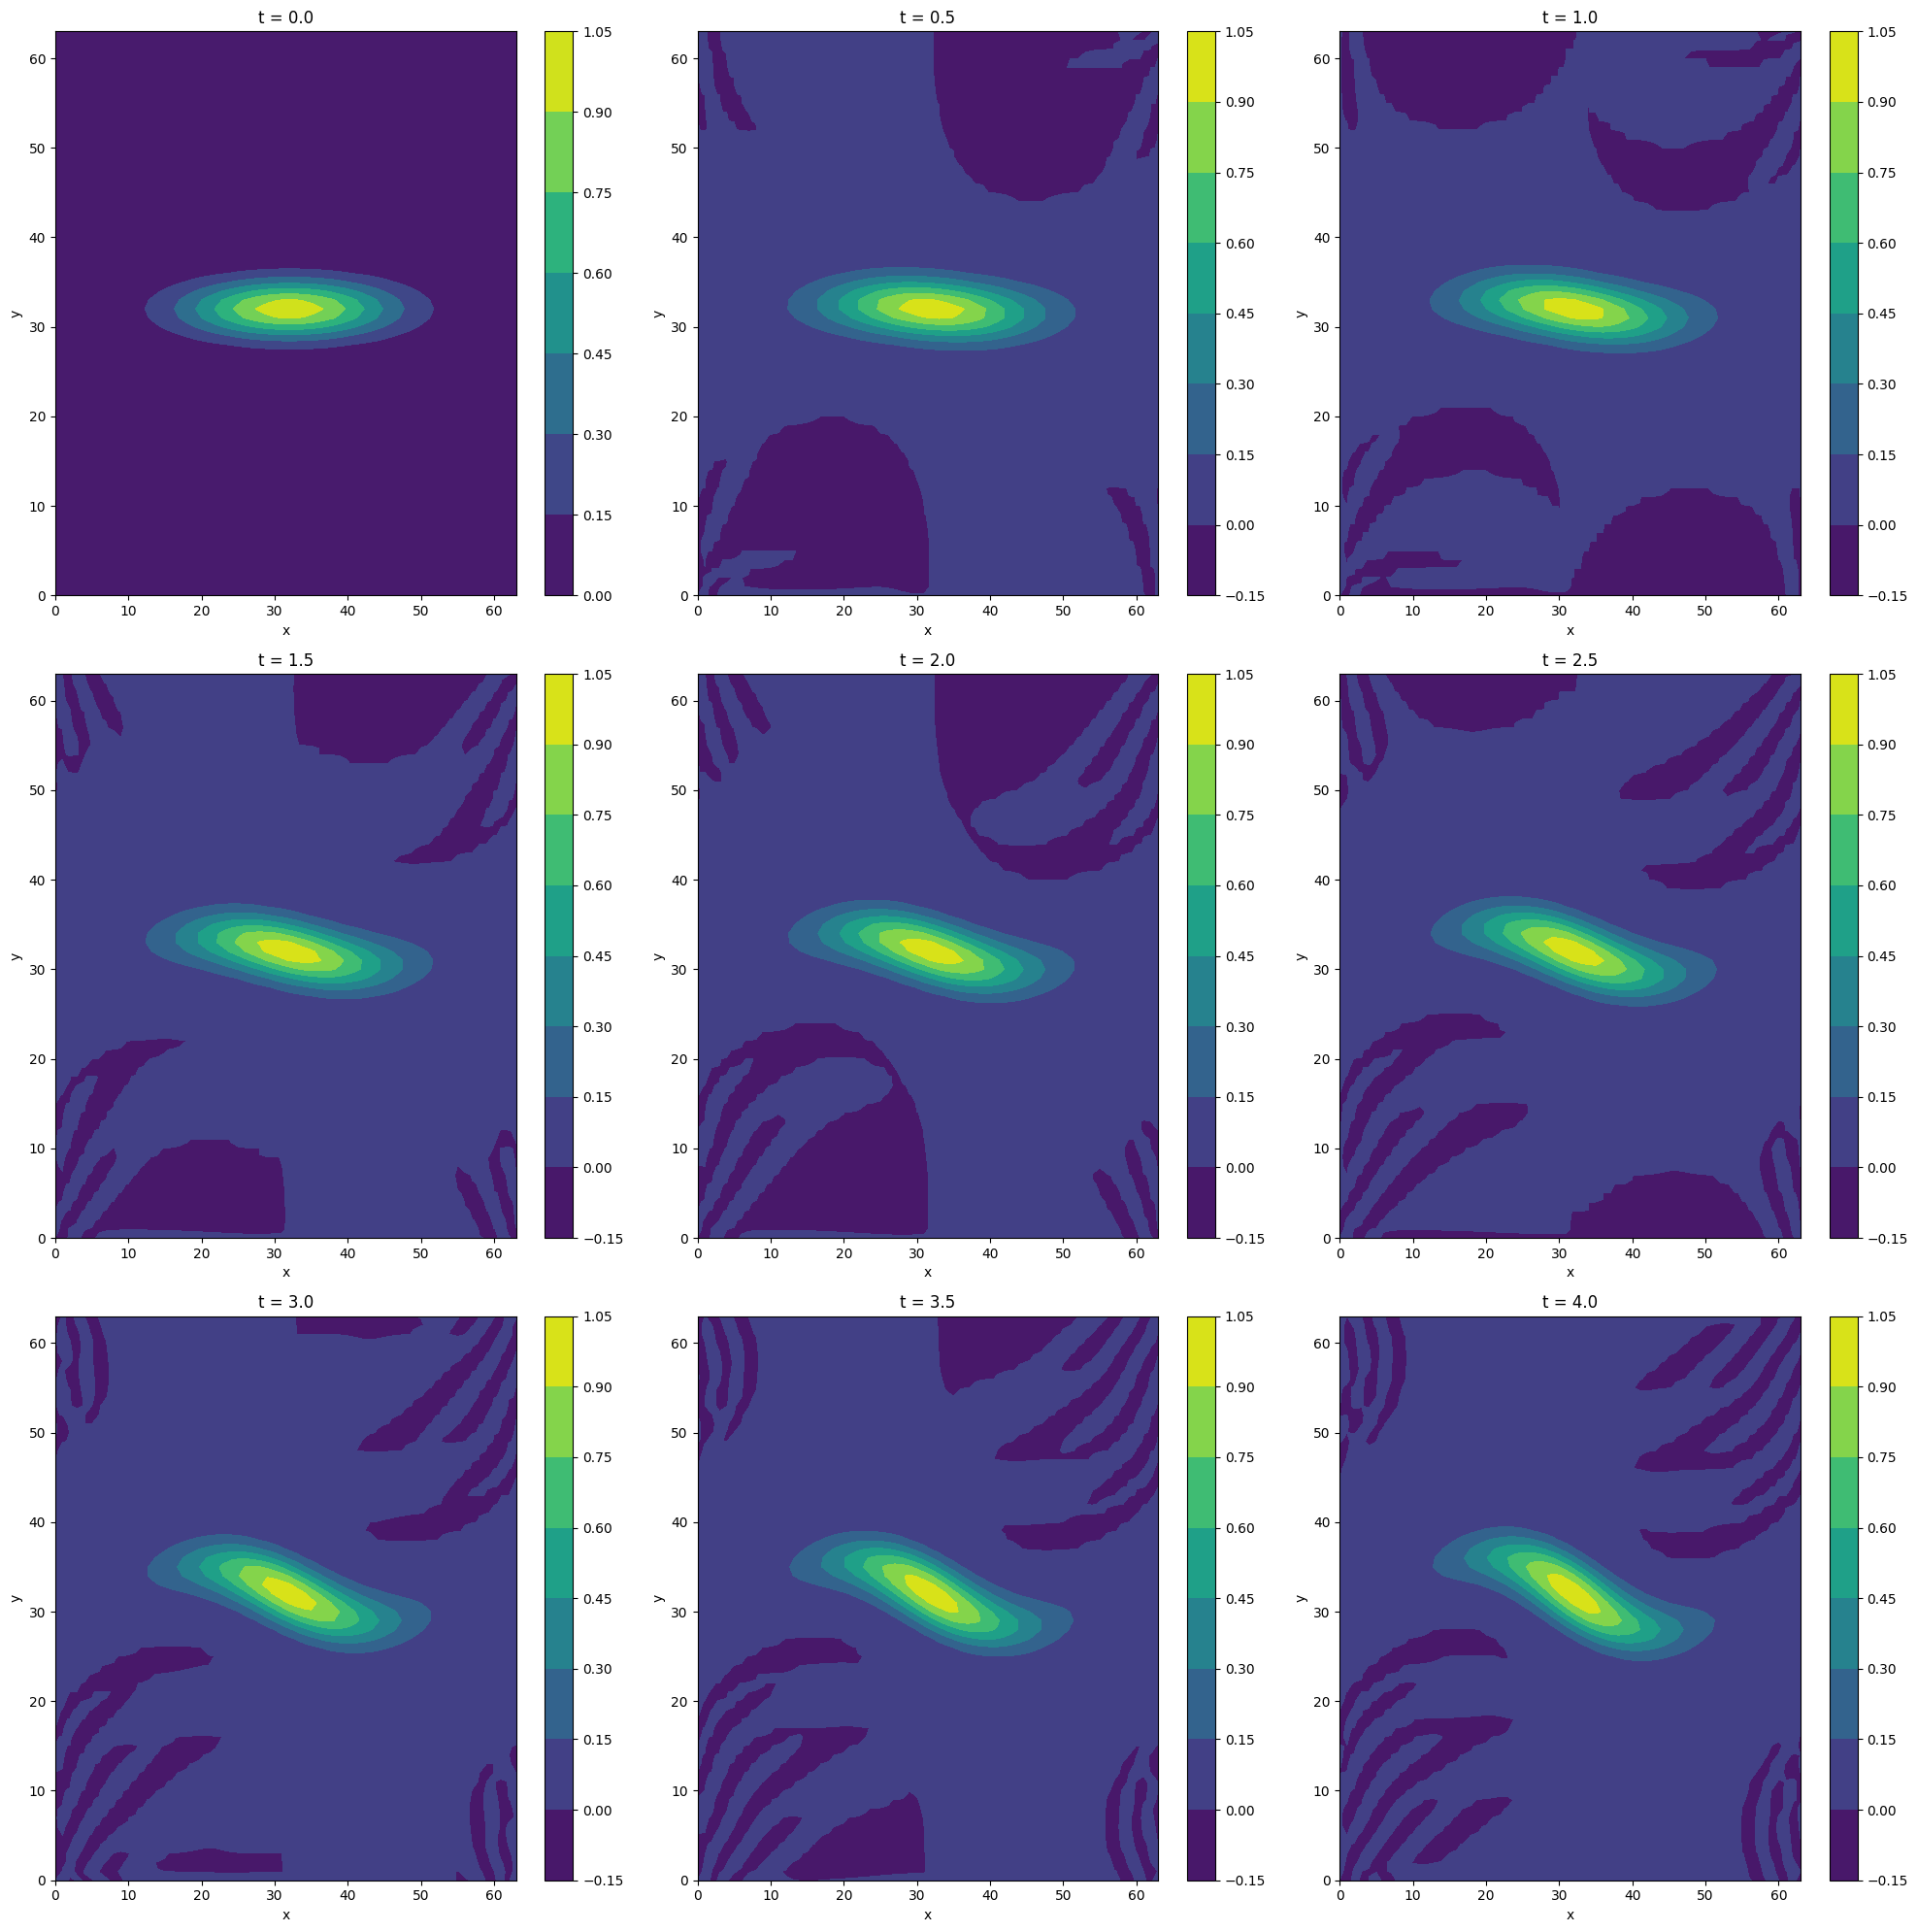

In [2]:
fig, axa = plt.subplots(3, 3, figsize=(20,20))
for ax, i in zip(axa.ravel(), range(len(t_eval))):
    image = np.real(A1[i,:size].reshape((steps, steps)))
    cp = ax.contourf(image,cmap = 'viridis');
    fig.colorbar(cp, ax = ax)
    ax.set_title("t = " + str(t_eval[i]))
    ax.set_xlabel('x')
    ax.set_ylabel('y')
plt.tight_layout()

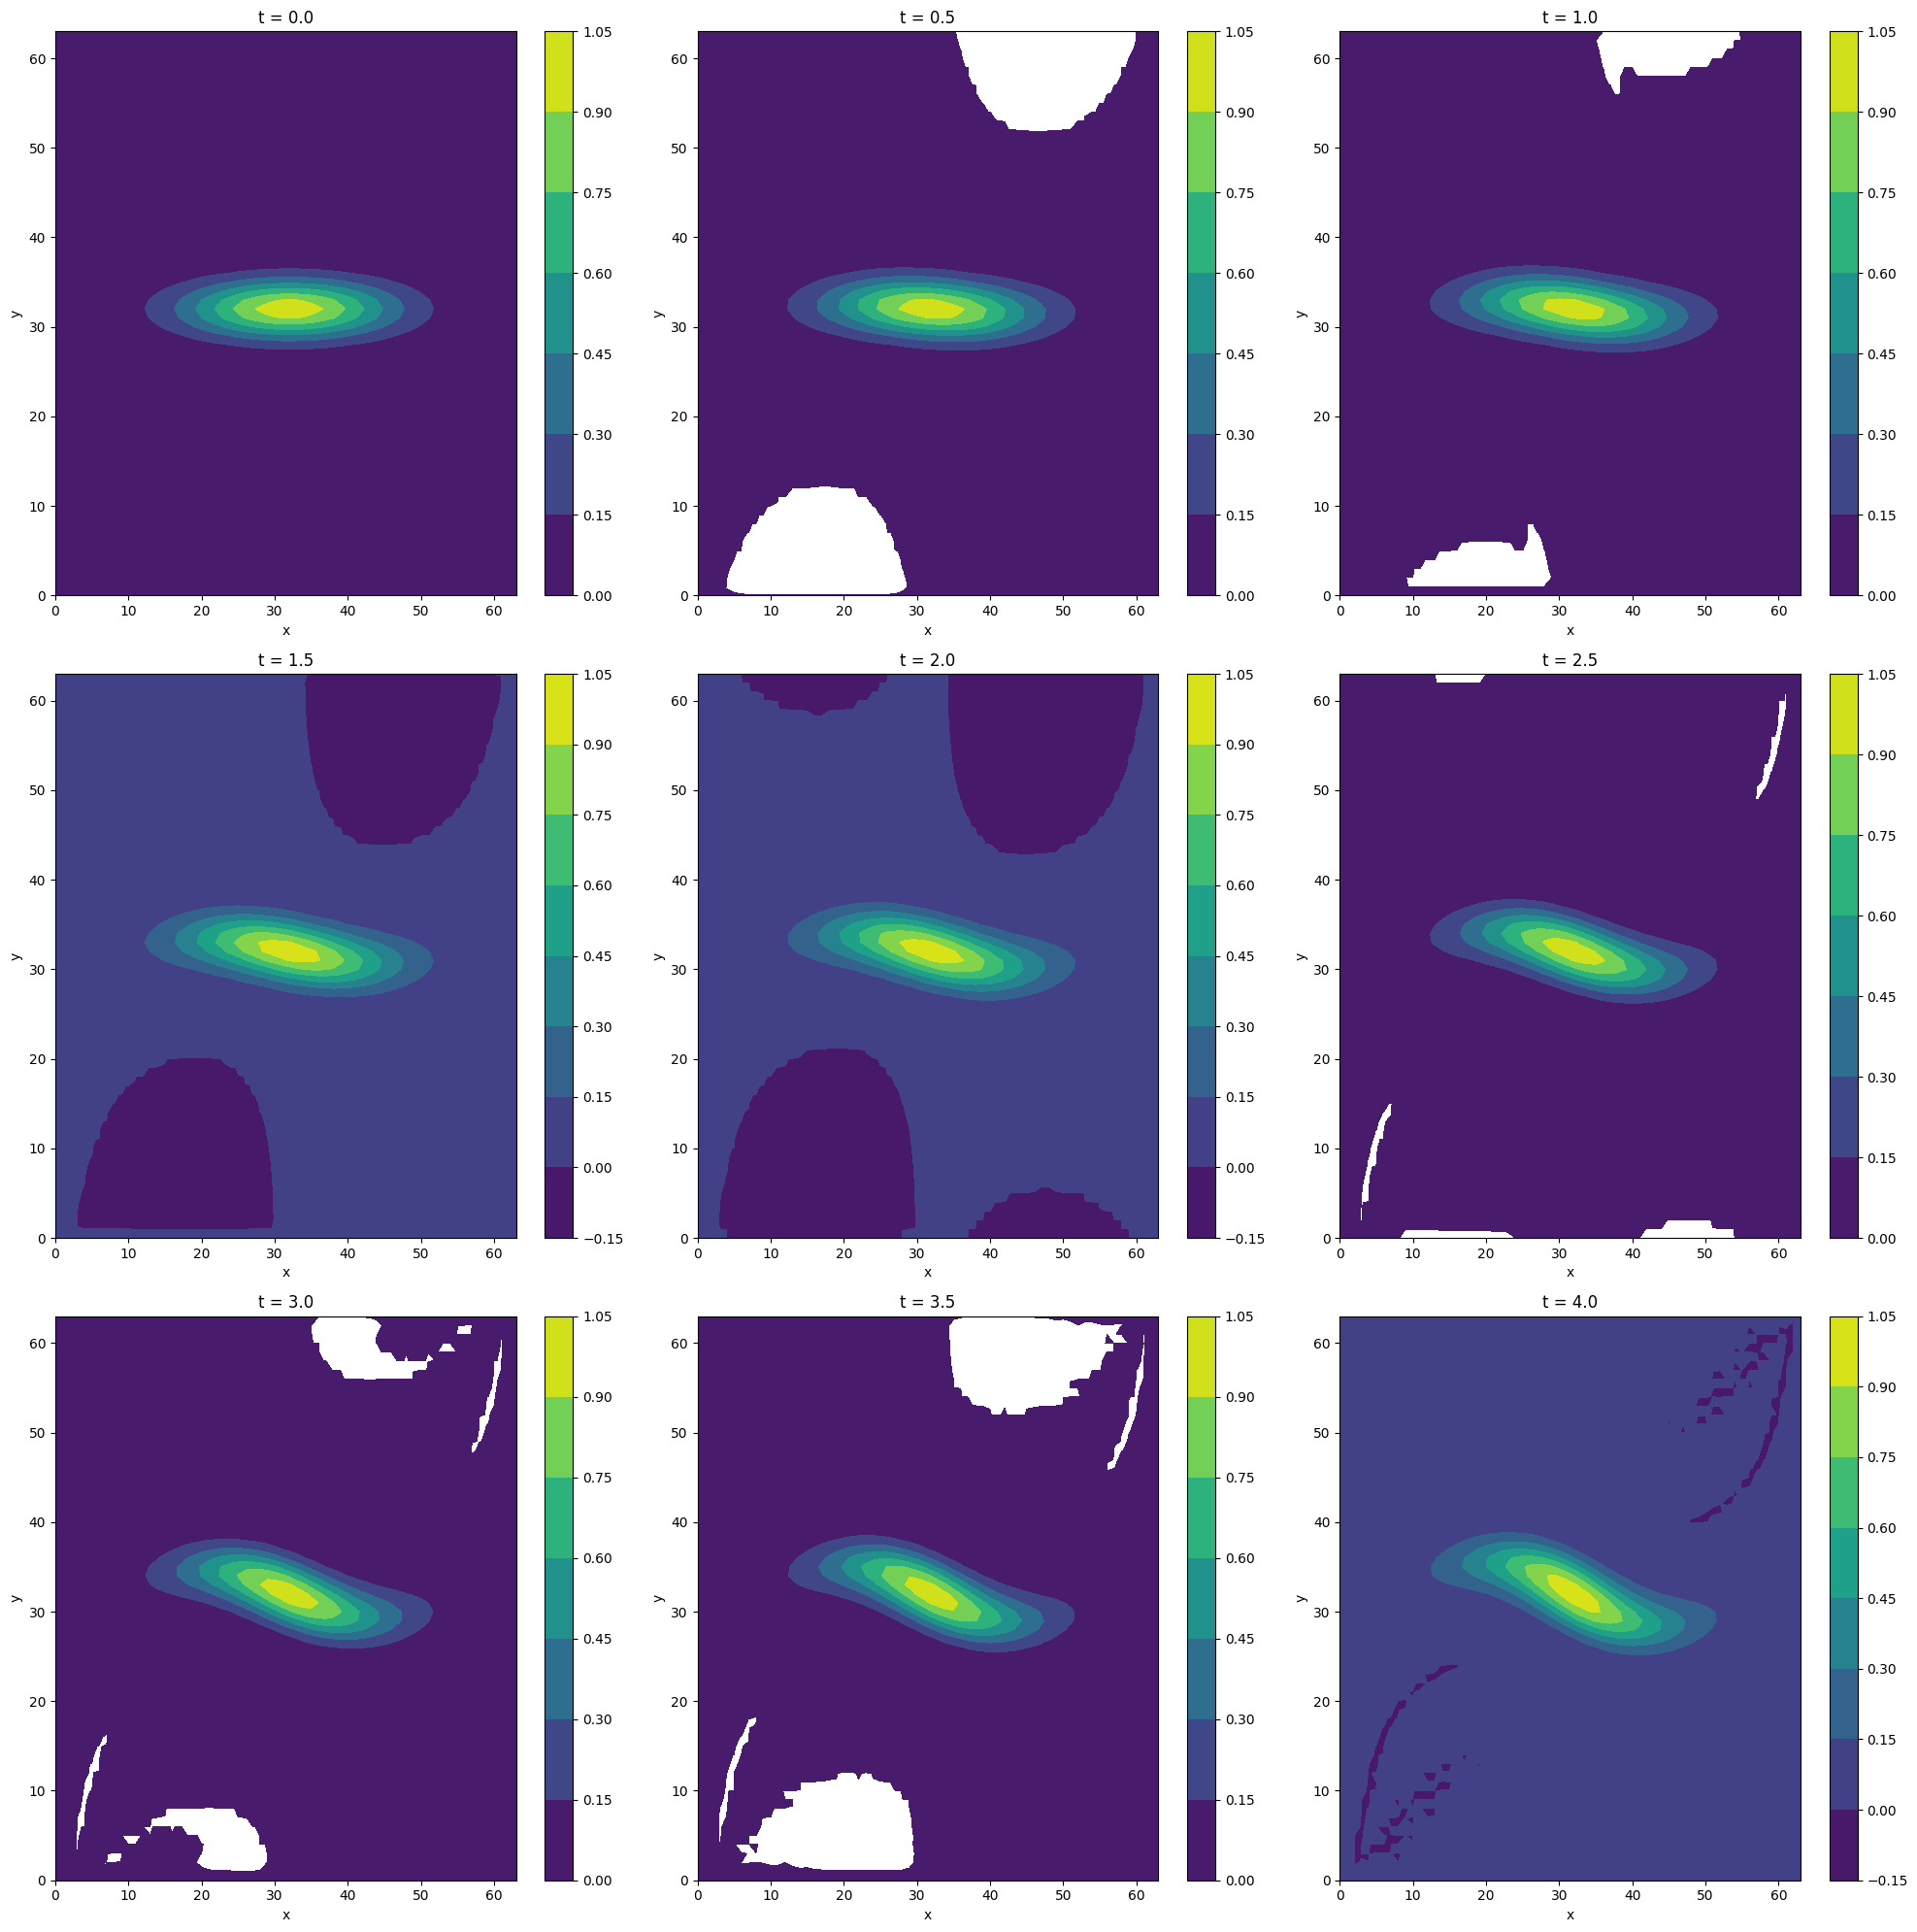

In [3]:
fig, axa = plt.subplots(3, 3, figsize=(20,20))
for ax, i in zip(axa.ravel(), range(len(t_eval))):
    image = np.real(A5[i,:size].reshape((steps, steps)))
    cp = ax.contourf(image,cmap = 'viridis');
    fig.colorbar(cp, ax = ax)
    ax.set_title("t = " + str(t_eval[i]))
    ax.set_xlabel('x')
    ax.set_ylabel('y')
plt.tight_layout()